## 1. Setting the background

Gas flaring is the controlled burning of natural gas associated with oil and gas extraction. It has persisted since the dawn of the oil industry over 160 years ago. Despite its long history, the practice remains a pervasive global challenge. The gas is wastefully flared for a variety of reasons, ranging from market and economic constraints, to a lack of capture infrastructure, to the absence of effective and enforced regulations, and a lack of operational priority by field operators.

According to a report published by the International Energy Agency(2024), around 139 billion cubic meters (bcm) of natural gas was flared globally; equivalent to the entire annual gas consumption of sub-Saharan Africa, resulting in approximately 500 million tonnes of CO₂ equivalent emissions. Despite growing awareness and international commitments to reduce emissions, gas flaring levels remain persistently high in several countries.

The primary objective of this project is to develop a robust **supervised machine learning regression model** capable of predicting the precise annual flaring volume (in million m³) at individual oil and gas extraction sites.

In [506]:
#Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

In [507]:
#Load the dataset
df=pd.read_csv (r'C:\Users\hp\Documents\Gas_Flaring_Prediction\Gas_Flaring_Data.csv', encoding='latin-1')
df.head()

,Country,Latitude,Longitude,bcm,MMscfd,Year,Field Type,Field Name,Field Operator,Location,Flare Level,Flaring Vol (million m3)
0,Albania,40.7481,19.6577,0.000,0.000,2012,OIL,Patos-Marinza,Bankers Petroleum,ONSHORE,Small,0.00
1,Algeria,31.7834,8.5865,0.000,0.000,2012,OIL,BMS,CEPSA,ONSHORE,Small,0.00
2,Algeria,30.6116,8.2620,0.090,8.753,2012,OIL,Rhourde Khrouf,CEPSA,ONSHORE,Medium,90.47
3,Algeria,32.0726,5.3528,0.022,2.133,2012,OIL,Guellala NE,CNPC,ONSHORE,Small,22.05
4,Algeria,31.2322,8.5630,0.123,11.917,2012,OIL,BRN,Eni,ONSHORE,Medium,123.17


## 2. Data Cleaning

In [508]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 156397 entries, 0 to 156396
Data columns (total 12 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Country                   156397 non-null  str    
 1   Latitude                  156397 non-null  float64
 2   Longitude                 156397 non-null  float64
 3   bcm                       156397 non-null  float64
 4   MMscfd                    156397 non-null  float64
 5   Year                      156397 non-null  int64  
 6   Field  Type               86747 non-null   str    
 7   Field Name                138494 non-null  str    
 8   Field  Operator           136167 non-null  str    
 9   Location                  156397 non-null  str    
 10  Flare Level               156397 non-null  str    
 11  Flaring Vol (million m3)  156397 non-null  str    
dtypes: float64(4), int64(1), str(7)
memory usage: 14.3 MB


In [509]:
#columns
df.columns

Index(['Country', 'Latitude', 'Longitude', 'bcm', 'MMscfd', 'Year',
       'Field  Type', 'Field Name', 'Field  Operator', 'Location',
       'Flare Level', 'Flaring Vol (million m3)'],
      dtype='str')

In [510]:
#Remove the white spaces from the columns
df.columns = df.columns.str.replace(' ', '')

In [511]:
df.columns

Index(['Country', 'Latitude', 'Longitude', 'bcm', 'MMscfd', 'Year',
       'FieldType', 'FieldName', 'FieldOperator', 'Location', 'FlareLevel',
       'FlaringVol(millionm3)'],
      dtype='str')

In [512]:
#Data Shape
df.shape

(156397, 12)

In [513]:
#check for duplicates
all_duplicates=df.duplicated()
print(all_duplicates)

0         False
1         False
2         False
3         False
4         False
          ...  
156392    False
156393    False
156394    False
156395    False
156396    False
Length: 156397, dtype: bool


In [514]:
all_duplicates=df.duplicated().sum()
print(all_duplicates)

68


In [515]:
all_duplicates=df.duplicated().value_counts()
print(all_duplicates)

False    156329
True         68
Name: count, dtype: int64


In [516]:
df = df.drop_duplicates()

- This a regression task. Our target variable 'FlaringVol(millionm3)' is stored as a string. We shall convert it to a float because regression algorithms require continuous or discrete numerical values to calculate errors and minimize loss functions.      

In [517]:
# Convert the target variable 'FlaringVol(millionm3) to a float
cols=['Latitude','Longitude','bcm','MMscfd', 'FlaringVol(millionm3)']
df[cols]=df[cols].apply(pd.to_numeric,errors='coerce')

In [518]:
df.info()

<class 'pandas.DataFrame'>
Index: 156329 entries, 0 to 156396
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Country                156329 non-null  str    
 1   Latitude               156329 non-null  float64
 2   Longitude              156329 non-null  float64
 3   bcm                    156329 non-null  float64
 4   MMscfd                 156329 non-null  float64
 5   Year                   156329 non-null  int64  
 6   FieldType              86743 non-null   str    
 7   FieldName              138490 non-null  str    
 8   FieldOperator          136163 non-null  str    
 9   Location               156329 non-null  str    
 10  FlareLevel             156329 non-null  str    
 11  FlaringVol(millionm3)  156306 non-null  float64
dtypes: float64(5), int64(1), str(6)
memory usage: 15.5 MB


In [519]:
# Transform temporal data to correct format
df['Year']=pd.to_datetime(df['Year'])
df.info()

<class 'pandas.DataFrame'>
Index: 156329 entries, 0 to 156396
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Country                156329 non-null  str           
 1   Latitude               156329 non-null  float64       
 2   Longitude              156329 non-null  float64       
 3   bcm                    156329 non-null  float64       
 4   MMscfd                 156329 non-null  float64       
 5   Year                   156329 non-null  datetime64[ns]
 6   FieldType              86743 non-null   str           
 7   FieldName              138490 non-null  str           
 8   FieldOperator          136163 non-null  str           
 9   Location               156329 non-null  str           
 10  FlareLevel             156329 non-null  str           
 11  FlaringVol(millionm3)  156306 non-null  float64       
dtypes: datetime64[ns](1), float64(5), str(6)
memory usage: 15.5 

In [520]:
#Let's handle missing values
df.isnull().sum()

Country                      0
Latitude                     0
Longitude                    0
bcm                          0
MMscfd                       0
Year                         0
FieldType                69586
FieldName                17839
FieldOperator            20166
Location                     0
FlareLevel                   0
FlaringVol(millionm3)       23
dtype: int64

In [521]:
missing_percent = (df.isnull().sum() / len(df)) * 100
print("Missing Values Percentage:")
print(missing_percent.sort_values(ascending=False))

Missing Values Percentage:
FieldType                44.512534
FieldOperator            12.899718
FieldName                11.411191
FlaringVol(millionm3)     0.014713
bcm                       0.000000
Longitude                 0.000000
Latitude                  0.000000
Country                   0.000000
MMscfd                    0.000000
Year                      0.000000
Location                  0.000000
FlareLevel                0.000000
dtype: float64


<Axes: >

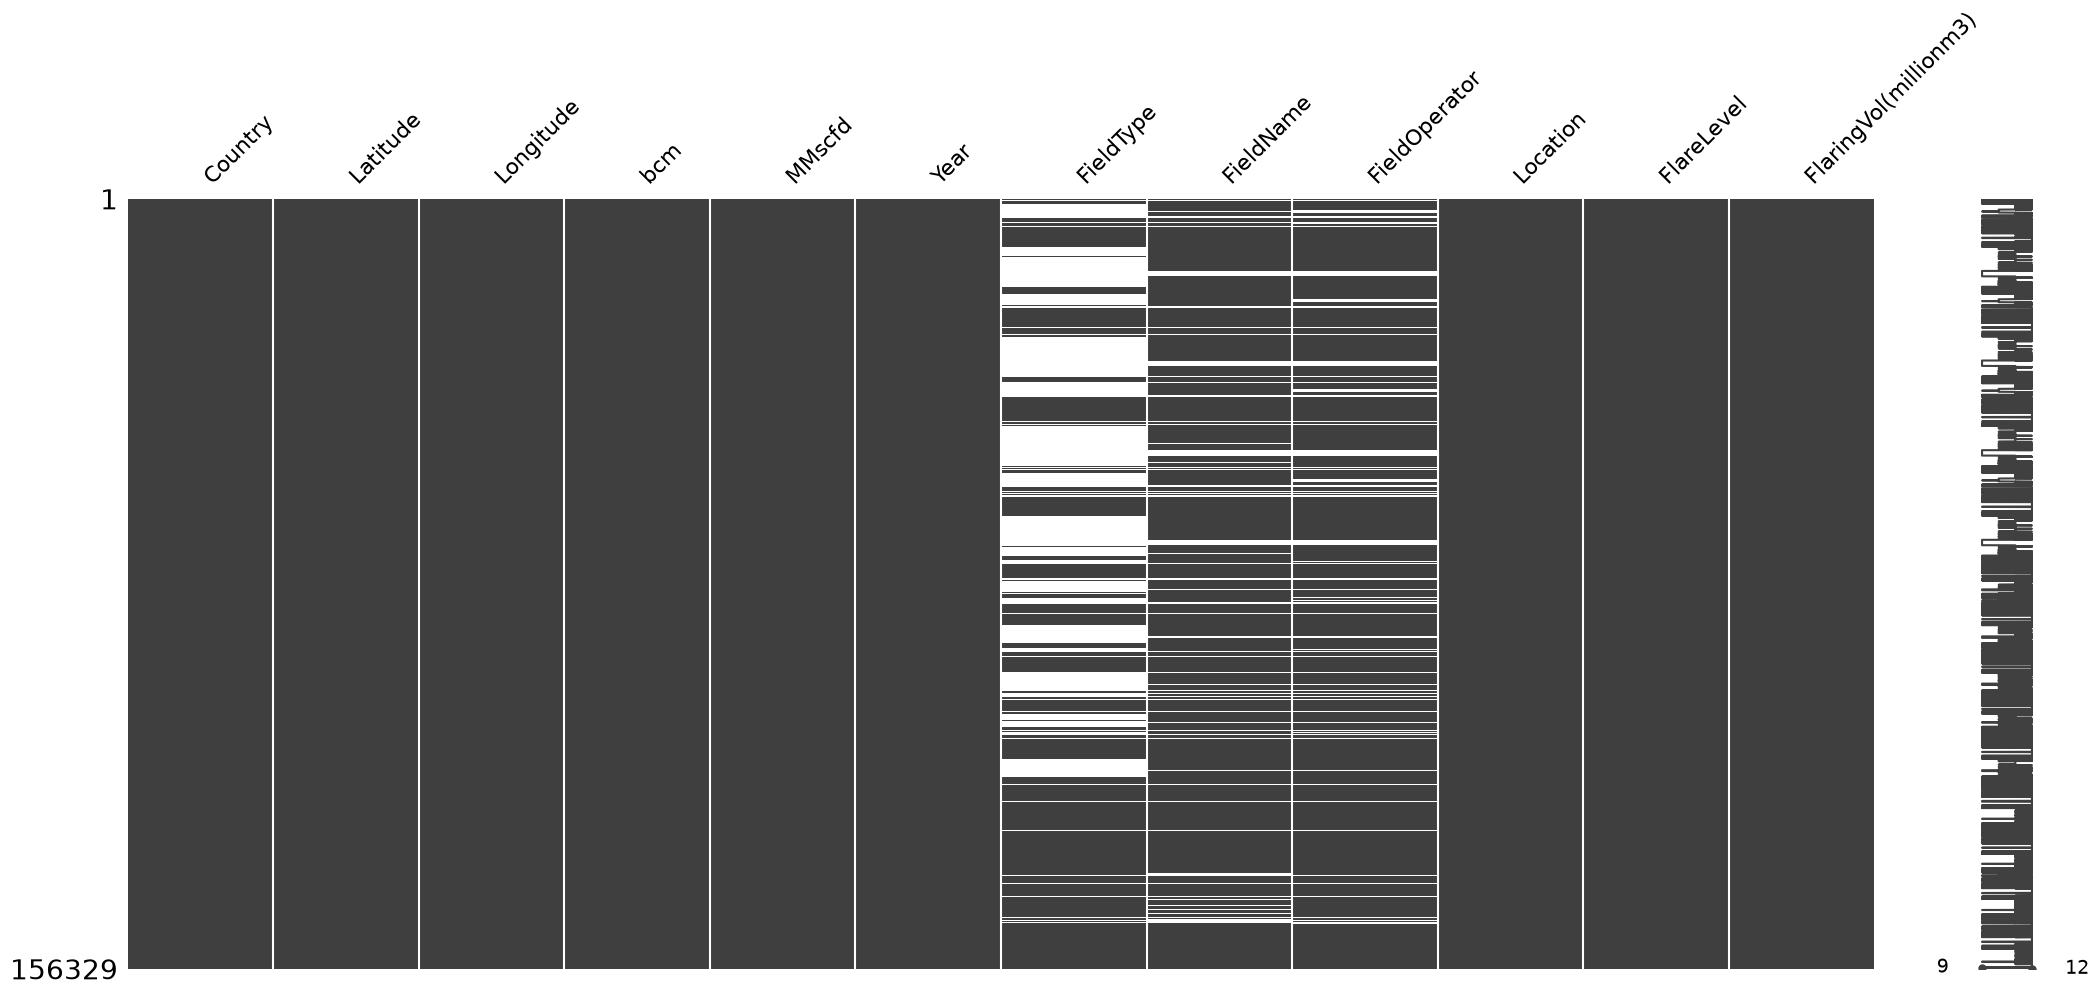

In [522]:
import missingno as msno
msno.matrix(df)


- From the above visualization, we can infer that when the Field Type is missing the Field Name and Field Operator are also missing. It is highly correlated across these specific columns.


In [523]:
#Check the number of unique values on each column
Result=df.nunique()
print(Result)

Country                    101
Latitude                 72946
Longitude                78743
bcm                       3533
MMscfd                   11073
Year                        13
FieldType                    3
FieldName                 8021
FieldOperator             2656
Location                     2
FlareLevel                   3
FlaringVol(millionm3)    11241
dtype: int64


### Strategy for handling missingness
- Field Name has 8021 unique values. Even if we filled the 11.4% of missing values, this column has over 8,000 unique values. If we one-hot encode it, we will massively overfit. If we label-encode it, the model will treat 'Field A' as numerically close to "Field B" when they have no actual relationship. This column is a unique ID, not a predictive feature. We can therefore drop it.

In [524]:
df.drop('FieldName', axis=1, inplace=True)
print("Dropped 'FieldName'.")


Dropped 'FieldName'.


In [525]:
df.info()

<class 'pandas.DataFrame'>
Index: 156329 entries, 0 to 156396
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Country                156329 non-null  str           
 1   Latitude               156329 non-null  float64       
 2   Longitude              156329 non-null  float64       
 3   bcm                    156329 non-null  float64       
 4   MMscfd                 156329 non-null  float64       
 5   Year                   156329 non-null  datetime64[ns]
 6   FieldType              86743 non-null   str           
 7   FieldOperator          136163 non-null  str           
 8   Location               156329 non-null  str           
 9   FlareLevel             156329 non-null  str           
 10  FlaringVol(millionm3)  156306 non-null  float64       
dtypes: datetime64[ns](1), float64(5), str(5)
memory usage: 14.3 MB


- There are 12.8% missing values in the Field Operator column. We shall fill the missing values with a new category called 'Unknown'. By doing this, the model can still learn patterns. For example, Unknown operators tend to be smaller fields with less flaring. 

In [526]:
df['FieldOperator'] = df['FieldOperator'].fillna('Unknown')
print("Filled missing Operators with 'Unknown'.")

Filled missing Operators with 'Unknown'.


In [527]:
print(df['FieldType'].value_counts())


FieldType
OIL    66784
GAS    19402
LNG      557
Name: count, dtype: int64


- There are 44.5% missing values in the Field Type column. Field has only 3 categories (OIL, GAS, LNG, NA), we shall use mode imputation.
- Most fields in the dataset are OIL fields (by a large margin). Therefore if Field Type is missing, it is probably OIL.

In [528]:
most_common_type = df['FieldType'].mode()[0] 
df['FieldType'] = df['FieldType'].fillna(most_common_type)


In [529]:
df.isnull().sum()

Country                   0
Latitude                  0
Longitude                 0
bcm                       0
MMscfd                    0
Year                      0
FieldType                 0
FieldOperator             0
Location                  0
FlareLevel                0
FlaringVol(millionm3)    23
dtype: int64

In [530]:
#Let's drop the missing values in the target variable
df.dropna(subset=['FlaringVol(millionm3)'],inplace=True)

In [531]:
df.isnull().sum()

Country                  0
Latitude                 0
Longitude                0
bcm                      0
MMscfd                   0
Year                     0
FieldType                0
FieldOperator            0
Location                 0
FlareLevel               0
FlaringVol(millionm3)    0
dtype: int64

In [532]:
df.dropna(inplace=True)

### Outlier Detection

In [533]:
#separte the dataframe into numerical and categorical data
num_df=df.select_dtypes(include=[np.number])
cat_df=df.select_dtypes(include=[object])

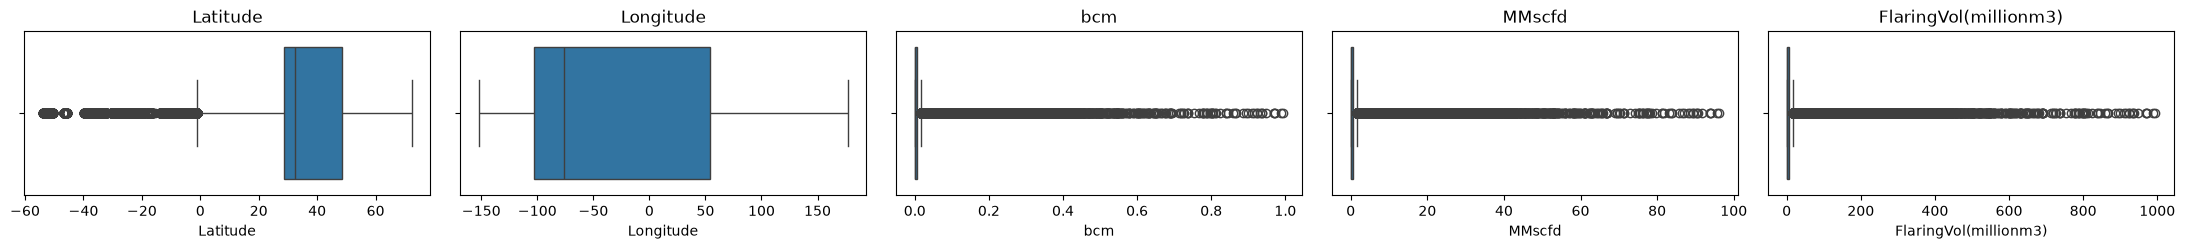

In [534]:
fig = plt.figure(figsize=(22,20))
for i in range(len(num_df.columns)):
    ax=fig.add_subplot(9, 5, i+1)
    sns.boxplot(x=num_df.iloc[:, i],ax=ax)
    ax.set_title(num_df.columns[i])
plt.tight_layout()
plt.show()

- There are significant outliers in the latitude, bcm, MMscfd and Flaring Vol columns.The outliers represent giant oil and gas fields that produce and flare massive amounts of gas. We shall address the outliers through feature scaling.

## 3. Exploratory Data Analysis

### 3.1 Univariate Analysis

### 3.1.1 Numerical Variable Distribution Analysis

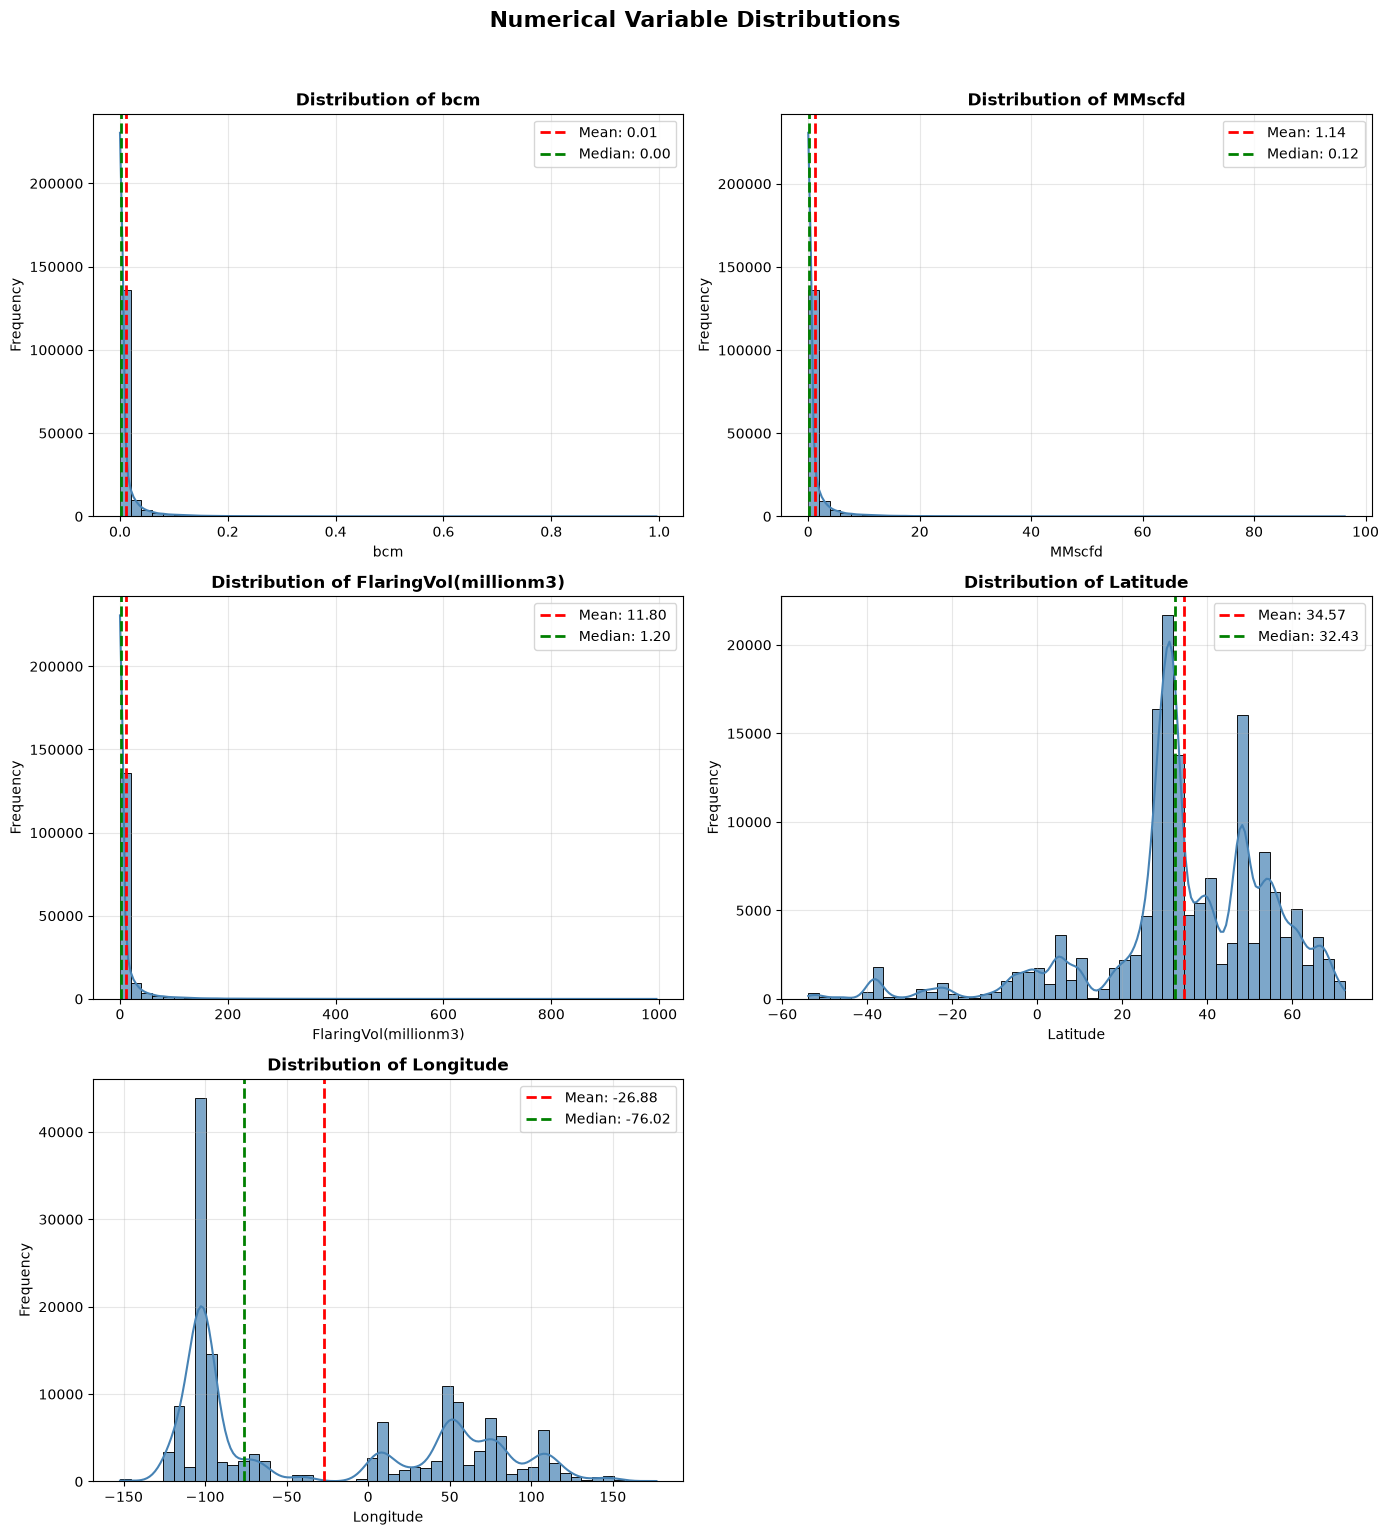

In [535]:
num_cols = ['bcm', 'MMscfd', 'FlaringVol(millionm3)', 'Latitude', 'Longitude']

n_cols = 2
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))

if n_rows == 1:
    axes = axes.reshape(1, -1)
else:
    axes = axes.flatten()

for i in range(len(num_cols), len(axes)):
    axes[i].axis('off')

for i, col in enumerate(num_cols):

    if col not in df.columns:
        continue
        
    data = df[col].dropna()
    
    # Histogram 
    sns.histplot(data, bins=50, kde=True, color='steelblue', edgecolor='black', alpha=0.7, ax=axes[i])
    
    # Add vertical lines for mean and median
    axes[i].axvline(data.mean(), color='red', linestyle='--', linewidth=2, 
                    label=f'Mean: {data.mean():.2f}')
    axes[i].axvline(data.median(), color='green', linestyle='--', linewidth=2, 
                    label=f'Median: {data.median():.2f}')
    
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].legend(loc='upper right')
    axes[i].grid(alpha=0.3)

plt.suptitle('Numerical Variable Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**bcm (Billion Cubic Meters) Distribution**
- The data is heavily right-skewed and most fields produce minimal gas (near 0 bcm). We can infer that a small number of super-giant fields produce the vast majority of gas.It is a confirmation that gas production is dominated by a few large fields.

**MMscfd (Million Standard Cubic Feet per Day) Distribution**
- We observe a similar pattern to bcm; the data is heavily right-skewed. The Daily gas production rates follow the same trend as total production. 

**Flaring Volume Distribution**
- The data is heavily right-skewed. Most fields flare very little (< 10 million m³). It is very likely that a few giant fields are responsible for the vast majority of flaring emissions.


### 3.1.2 Categorical Variable Distribution Analysis

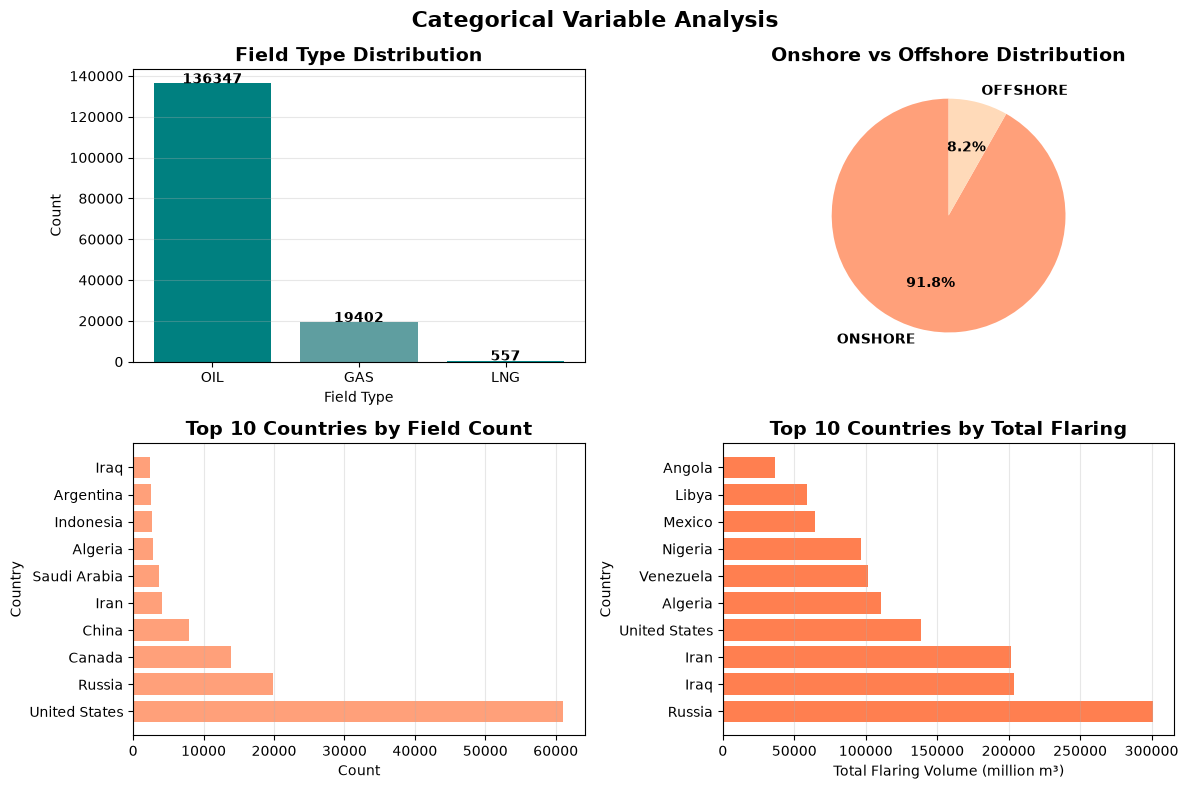

In [536]:
# Categorical Variables
fig, axes = plt.subplots(2,2, figsize=(12, 8))

# 1. Field Type Distribution
field_type_counts = df['FieldType'].value_counts()
colors = ['teal','cadetblue', 'darkcyan']
axes[0, 0].bar(field_type_counts.index, field_type_counts.values, color=colors[:len(field_type_counts)])
axes[0, 0].set_title('Field Type Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Field Type')
axes[0, 0].set_ylabel('Count')
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(field_type_counts.values):
    axes[0, 0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# 2. Location Distribution
location_counts = df['Location'].value_counts()
axes[0, 1].pie(location_counts.values, labels=location_counts.index, autopct='%1.1f%%', 
               colors=['lightsalmon','peachpuff'], startangle=90, textprops={'fontweight': 'bold'})
axes[0, 1].set_title('Onshore vs Offshore Distribution', fontsize=14, fontweight='bold')

# 3. Top 10 Countries by Field Count
country_counts = df['Country'].value_counts().head(10)
axes[1, 0].barh(country_counts.index, country_counts.values, color='lightsalmon')
axes[1, 0].set_title('Top 10 Countries by Field Count', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Count')
axes[1, 0].set_ylabel('Country')
axes[1, 0].grid(axis='x', alpha=0.3)

# 4. Top 10 Countries by Total Flaring
country_flaring = df.groupby('Country')['FlaringVol(millionm3)'].sum().sort_values(ascending=False).head(10)
axes[1, 1].barh(country_flaring.index, country_flaring.values, color='coral')
axes[1, 1].set_title('Top 10 Countries by Total Flaring', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Total Flaring Volume (million m³)')
axes[1, 1].set_ylabel('Country')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.suptitle('Categorical Variable Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


**Field Type Distribution**
- OIL fields dominate the dataset, comprising 136,347 records. GAS fields are the second most common with a record of 19,402. While LNG facilities represent only 557 records of the dataset. The predominance of OIL fields is expected, as gas flaring is primarily associated with oil extraction. When oil is extracted, associated gas is often flared due to lack of infrastructure or economic constraints. This makes OIL fields the primary target for flaring reduction efforts. Any flaring reduction strategy should prioritize OIL fields, as they represent both the largest share of fields and the highest flaring volumes.

**Location Distribution (Onshore vs Offshore)**
- Onshore fields dominate at 91.8% of all fields while Offshore fields represent only 8.2% of the dataset. The overwhelming majority of fields are located onshore. This has significant implications on flaring. Onshore fields generally have more infrastructure options for gas capture and utilization. However, onshore fields also face regulatory and economic barriers that may perpetuate flaring. Offshore fields face space and safety constraints that can make gas capture more challenging. Onshore fields represent the largest opportunity for flaring reduction through infrastructure investment and regulatory enforcement. Offshore fields, while fewer, may require different technological solutions.

**Top 10 Countries by Field Count**
- United States leads the dataset with the highest number of fields. Russia and Canada follow closely. The distribution shows global representation across major oil-producing regions. The concentration of fields in specific countries reflects global oil and gas production patterns. Countries with the most fields also tend to have the highest flaring volumes, though this relationship varies based on regulatory frameworks and infrastructure. Countries with high field counts may present the largest opportunities for flaring reduction. However, field count alone does not determine flaring volume; regulatory effectiveness and infrastructure availability are equally important factors.

**Top 10 Countries by Total Flaring Volume**
- The countries with the highest total flaring volume may differ from those with the most fields. A few countries account for the majority of global flaring. This chart reveals which countries contribute most to global gas flaring. While Russia may be among the countries that have the most fields, countries like Iraq and Iran may rank higher in total flaring volume due to differences in:
    - Flaring intensity per field.
    - Regulatory enforcement.
    - Infrastructure investment.
    - Economic incentives for gas capture.
- Flaring reduction efforts should prioritize countries with the highest total flaring volume, as these represent the greatest opportunities for emissions reduction.

### 3.2 Bivariate Analysis

### 3.2.1 Numerical Features v Target Variable

In [537]:
num_cols = ['bcm', 'MMscfd', 'FlaringVol(millionm3)', 'Latitude', 'Longitude']


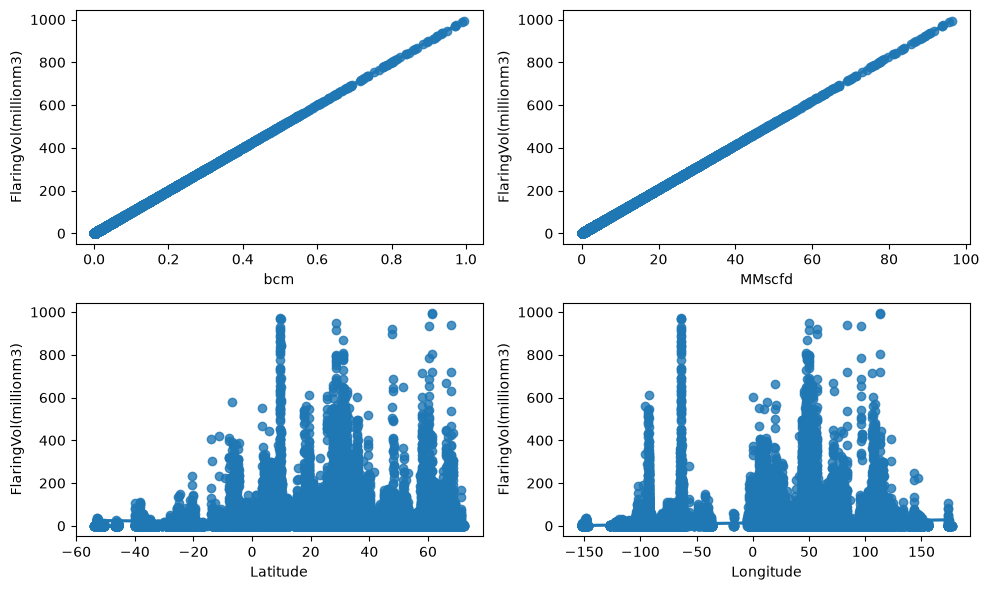

In [538]:
# Relationship between numerical features and the target variable
fig, axs = plt.subplots(2, 2, figsize=(10, 6))

sns.regplot(x='bcm',y='FlaringVol(millionm3)',data=df,ax=axs[0,0])
sns.regplot(x='MMscfd',y='FlaringVol(millionm3)',data=df,ax=axs[0,1])
sns.regplot(x='Latitude',y='FlaringVol(millionm3)',data=df,ax=axs[1,0])
sns.regplot(x='Longitude',y='FlaringVol(millionm3)',data=df,ax=axs[1,1])


plt.tight_layout()
plt.show()

In [539]:
from scipy.stats import pearsonr

# Calculate correlation
corr, p_value = pearsonr(df['bcm'], df['FlaringVol(millionm3)'])

print(f"Correlation: {corr:.2f} (p-value: {p_value:.4f})")

Correlation: 1.00 (p-value: 0.0000)


- We observe a very strong positive correlation (1.00) between bcm (total gas production) and flaring volume.As bcm increases, flaring volume increases. Total gas production (bcm) is one of the strongest predictors of flaring volume. Giant fields produce massive amounts of gas, and a significant portion is flared.

In [540]:
from scipy.stats import pearsonr

# Calculate correlation
corr, p_value = pearsonr(df['MMscfd'], df['FlaringVol(millionm3)'])

print(f"Correlation: {corr:.2f} (p-value: {p_value:.4f})")

Correlation: 1.00 (p-value: 0.0000)


- There is a very strong positive correlation (1.00) between MMscfd (daily gas production) and flaring volume. As MMscfd increases, flaring volume tends to increase. MMscfd is also a strong predictor of flaring volume. Fields with higher daily gas production rates tend to flare more gas, because they produce more associated gas that needs to be managed.

In [541]:
from scipy.stats import pearsonr

# Calculate correlation
corr, p_value = pearsonr(df['Latitude'], df['FlaringVol(millionm3)'])

print(f"Correlation: {corr:.2f} (p-value: {p_value:.4f})")

Correlation: -0.08 (p-value: 0.0000)


- There is a weak negative correlation (-0.08) between latitude and flaring volume. Most flaring occurs between 20°N and 50°N (Northern Hemisphere). Flaring is geographically concentrated in major oil-producing regions of the Northern Hemisphere. This reflects the global distribution of oil and gas extraction.

In [542]:
from scipy.stats import pearsonr

# Calculate correlation
corr, p_value = pearsonr(df['Longitude'], df['FlaringVol(millionm3)'])

print(f"Correlation: {corr:.2f} (p-value: {p_value:.4f})")

Correlation: 0.17 (p-value: 0.0000)


- We observe a weak positive correlation (0.17) between longitude and flaring volume. The distribution of fields span from -150° to 150° longitude. Flaring occurs globally but is concentrated in specific regions. 

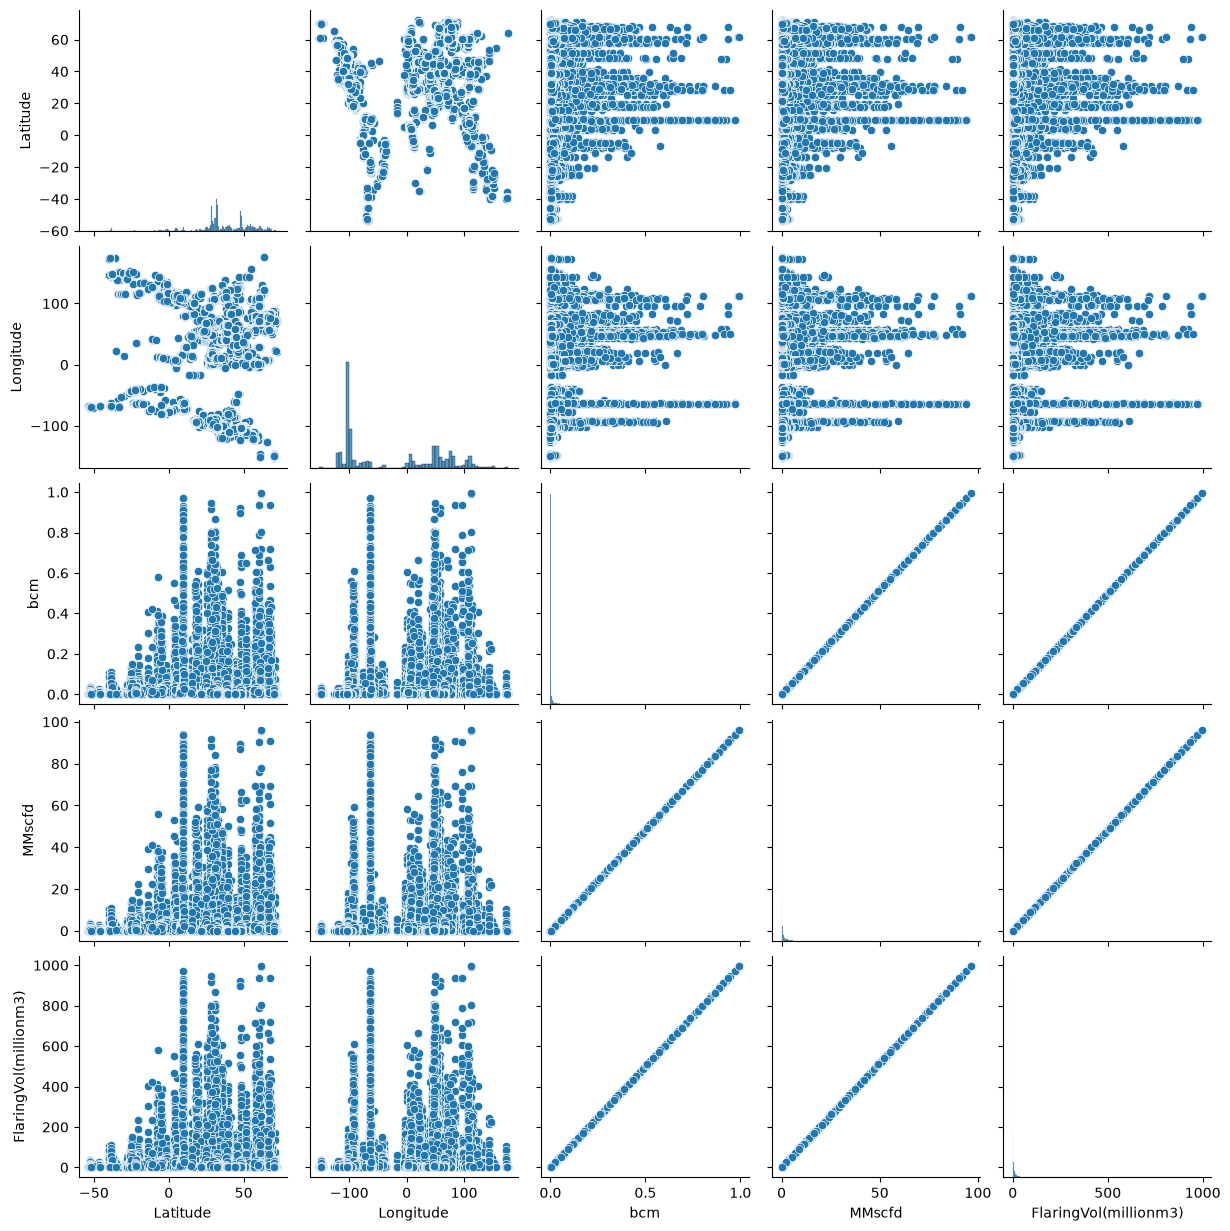

In [543]:
sns.pairplot(df)

- bcm and MMscfd are highly correlated with the target variable, Flaring Volume.

### 3.2.2. Categorical Features v Target Variable

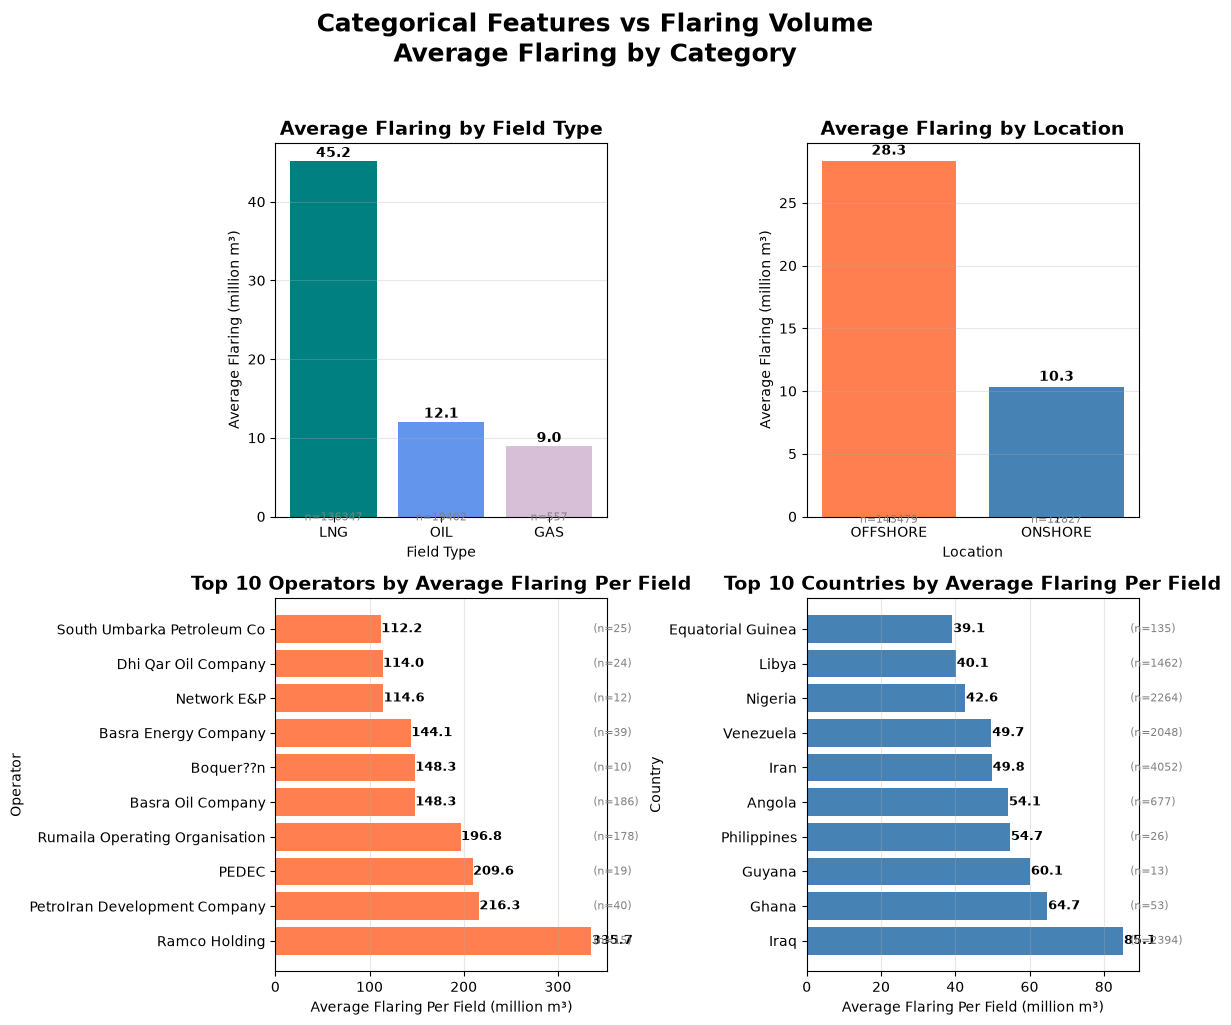

In [544]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Bar Chart: Average Flaring by Field Type
avg_by_type = df.groupby('FieldType')['FlaringVol(millionm3)'].mean().sort_values(ascending=False)
colors = ['teal', 'cornflowerblue', 'thistle']
bars = axes[0, 0].bar(avg_by_type.index, avg_by_type.values, color=colors[:len(avg_by_type)])
axes[0, 0].set_title('Average Flaring by Field Type', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Field Type')
axes[0, 0].set_ylabel('Average Flaring (million m³)')
axes[0, 0].grid(axis='y', alpha=0.3)

for i, v in enumerate(avg_by_type.values):
    axes[0, 0].text(i, v + 0.5, f'{v:.1f}', ha='center', fontweight='bold', fontsize=10)

# Add count labels
counts = df['FieldType'].value_counts()
for i, (idx, count) in enumerate(counts.items()):
    axes[0, 0].text(i, -0.5, f'n={count}', ha='center', fontsize=8, color='gray')

# 2. Bar Chart: Average Flaring by Location
avg_by_location = df.groupby('Location')['FlaringVol(millionm3)'].mean().sort_values(ascending=False)
colors = ['coral', 'steelblue']
bars = axes[0, 1].bar(avg_by_location.index, avg_by_location.values, color=colors)
axes[0, 1].set_title('Average Flaring by Location', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Location')
axes[0, 1].set_ylabel('Average Flaring (million m³)')
axes[0, 1].grid(axis='y', alpha=0.3)

for i, v in enumerate(avg_by_location.values):
    axes[0, 1].text(i, v + 0.5, f'{v:.1f}', ha='center', fontweight='bold', fontsize=10)

# Add count labels
counts_loc = df['Location'].value_counts()
for i, (idx, count) in enumerate(counts_loc.items()):
    axes[0, 1].text(i, -0.5, f'n={count}', ha='center', fontsize=8, color='gray')

# 3.Top Operators by Average Flaring Per Field
# Filter out operators with fewer than 10 fields
operator_counts = df['FieldOperator'].value_counts()
operators_with_min_fields = operator_counts[operator_counts >= 10].index
df_operators = df[df['FieldOperator'].isin(operators_with_min_fields)]

avg_operators = df_operators.groupby('FieldOperator')['FlaringVol(millionm3)'].mean().sort_values(ascending=False).head(10)

bars = axes[1, 0].barh(avg_operators.index, avg_operators.values, color='coral')
axes[1, 0].set_title('Top 10 Operators by Average Flaring Per Field', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Average Flaring Per Field (million m³)')
axes[1, 0].set_ylabel('Operator')
axes[1, 0].grid(axis='x', alpha=0.3)

max_val = avg_operators.max()
for i, v in enumerate(avg_operators.values):
    axes[1, 0].text(v + 0.3, i, f'{v:.1f}', va='center', fontweight='bold', fontsize=9)

# Add count labels
for i, (operator, val) in enumerate(avg_operators.items()):
    count = operator_counts[operator]
    axes[1, 0].text(max_val + 2, i, f'(n={count})', va='center', fontsize=8, color='gray')

# 4. Top Countries by Average Flaring Per Field
# Filter out countries with fewer than 10 fields
country_counts = df['Country'].value_counts()
countries_with_min_fields = country_counts[country_counts >= 10].index
df_countries = df[df['Country'].isin(countries_with_min_fields)]

avg_countries = df_countries.groupby('Country')['FlaringVol(millionm3)'].mean().sort_values(ascending=False).head(10)


bars = axes[1, 1].barh(avg_countries.index, avg_countries.values, color='steelblue')
axes[1, 1].set_title('Top 10 Countries by Average Flaring Per Field', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Average Flaring Per Field (million m³)')
axes[1, 1].set_ylabel('Country')
axes[1, 1].grid(axis='x', alpha=0.3)

max_val2 = avg_countries.max()
for i, v in enumerate(avg_countries.values):
    axes[1, 1].text(v + 0.3, i, f'{v:.1f}', va='center', fontweight='bold', fontsize=9)

# Add count labels
for i, (country, val) in enumerate(avg_countries.items()):
    count = country_counts[country]
    axes[1, 1].text(max_val2 + 2, i, f'(n={count})', va='center', fontsize=8, color='gray')


plt.suptitle('Categorical Features vs Flaring Volume\nAverage Flaring by Category', 
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



**Average Flaring by Field Type**
- LNG fields have the highest average flaring at 45.2 million m³, significantly higher than OIL and GAS fields. This is likely due to the large-scale processing and liquefaction operations that can produce substantial flaring during operational upsets or maintenance.OIL fields average 12.1 million m³, reflecting the common practice of flaring associated gas when infrastructure for gas capture is limited.GAS fields have the lowest average flaring at 9.0 million m³, as gas production typically involves more established gas handling and utilization infrastructure.

**Average Flaring by Location**
- Offshore locations show significantly higher average flaring at 28.3 million m³, nearly three times that of onshore locations. This is often due to:
    - Limited space for gas processing and reinjection equipment on platforms
    - Higher operational costs for gas capture offshore
    - Regulatory differences and challenges in transporting gas to shore
- Onshore locations average 10.3 million m³, benefiting from easier access to gas processing facilities, pipelines, and other gas utilization infrastructure.

**Top 10 Operators by Average Flaring Per Field**
- Ramco Holding has the highest average flaring at 335.7 million m³, significantly outpacing other operators. This indicates potentially large-scale operations with limited gas capture infrastructure.Petrolian Development Company and PEDEC follow closely with averages above 200 million m³. Both are active in Iran, a country with historically high flaring rates.
- Rumaila Operating Organisation (196.8 million m³) operates the super-giant Rumaila field in Iraq, one of the largest oil fields in the world.
- Basra Oil Company, Boquer??n, and Basra Energy Company all exceed 140 million m³, highlighting the concentration of high flaring among operators in the Middle East and Venezuela.
- Network E&P and South Umbarka Petroleum Co (both over 110 million m³) show that flaring is not confined to the Middle East but occurs in Africa as well.

**Top 10 Countries by Average Flaring Per Field**
- Iraq leads the list with an average of 85.1 million m³, driven by its super-giant fields like Rumaila and West Qurna, where associated gas flaring remains a significant challenge.
- Ghana (64.7 million m³) and Guyana (60.1 million m³) are emerging oil producers whose infrastructure for gas utilization is still developing, leading to higher flaring per field.
- Philippines (54.7 million m³) and Angola (54.1 million m³) represent countries where offshore production dominates and gas capture is logistically challenging.
- Iran and Venezuela both average near 50 million m³, reflecting their status as major oil producers with high flaring rates due to sanctions, infrastructure challenges, and lack of gas export routes.
- Nigeria (42.6 million m³), Libya (40.1 million m³), and Equatorial Guinea (39.1 million m³) show that flaring is a widespread issue across Africa, driven by both operational and regulatory factors.


### 3.3 Multivariate Analysis

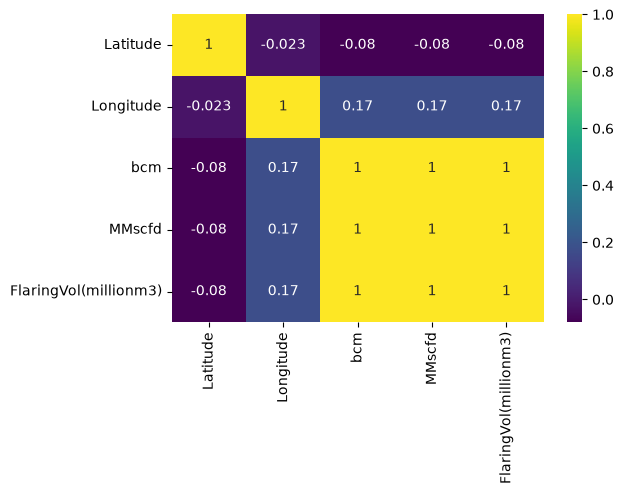

In [545]:
corrmat = num_df.corr()
top_corr_features = corrmat.index
plt.figure(figsize=(6,4))
g=sns.heatmap(num_df[top_corr_features].corr(),annot=True,cmap="viridis")

- bcm and MMscfd are highly correlated with each other.They measure the same thing. Keeping both will create severe multicollinearity.

In [546]:
#Variance Inflation Factor
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import warnings
warnings.filterwarnings('ignore')

In [547]:
clean_predictors = [
    'Latitude',
    'Longitude',
    'bcm'                  
]

# Create clean dataset
X_clean = df[clean_predictors]

print(f"Using {len(clean_predictors)} clean predictors:")
for pred in clean_predictors:
    print(f"{pred}")

# Check VIF for clean predictors
print("\n=== CLEAN PREDICTORS VIF ===")
X_const = add_constant(X_clean)

for i, col in enumerate(X_const.columns):
    if col != 'const':
        vif = variance_inflation_factor(X_const.values, i)
        status = "Good" if vif < 5 else "Moderate" if vif < 10 else "Severe"
        print(f"{status} {col:.<15} VIF: {vif:.1f}")

Using 3 clean predictors:
Latitude
Longitude
bcm

=== CLEAN PREDICTORS VIF ===
Good Latitude....... VIF: 1.0
Good Longitude...... VIF: 1.0
Good bcm............ VIF: 1.0


In [548]:
df.drop(columns=['MMscfd'],inplace=True)
df.info()

<class 'pandas.DataFrame'>
Index: 156306 entries, 0 to 156396
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Country                156306 non-null  str           
 1   Latitude               156306 non-null  float64       
 2   Longitude              156306 non-null  float64       
 3   bcm                    156306 non-null  float64       
 4   Year                   156306 non-null  datetime64[ns]
 5   FieldType              156306 non-null  str           
 6   FieldOperator          156306 non-null  str           
 7   Location               156306 non-null  str           
 8   FlareLevel             156306 non-null  str           
 9   FlaringVol(millionm3)  156306 non-null  float64       
dtypes: datetime64[ns](1), float64(4), str(5)
memory usage: 13.1 MB


## 4. Feature Engineering 


In [549]:
unique_values = df['Country'].unique().tolist()
print(unique_values)

['Albania', 'Algeria', 'Angola', 'Argentina', 'Australia', 'Austria', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Belarus', 'Bolivia', 'Brazil', 'Brunei Darussalam', 'Cameroon', 'Canada', 'Chad', 'Chile', 'China', 'Colombia', 'Congo', 'Croatia', 'Cuba', 'Democratic Republic of Congo', 'Denmark', 'Ecuador', 'Egypt', 'Equatorial Guinea', 'France', 'Gabon', 'Georgia', 'Ghana', 'Guatemala', 'Hungary', 'India', 'Indonesia', 'Iran', 'Iraq', 'Israel', 'Italy', 'Ivory Coast', 'Japan', 'Jordan', 'Kazakhstan', 'Kuwait', 'Libya', 'Malaysia', 'Mauritania', 'Mexico', 'Mongolia', 'Mozambique', 'Myanmar', 'Netherlands', 'New Zealand', 'Niger', 'Nigeria', 'Norway', 'Oman', 'Pakistan', 'Papua New Guinea', 'Peru', 'Philippines', 'Poland', 'Qatar', 'Romania', 'Russia', 'Saudi Arabia', 'Serbia', 'South Africa', 'Spain', 'Sudan', 'Sweden', 'Syria', 'Tanzania', 'Thailand', 'Timor-Leste', 'Trinidad and Tobago', 'Tunisia', 'Turkey', 'Turkmenistan', 'Ukraine', 'United Arab Emirates', 'United Kingdom', 'United Stat

In [550]:
REGION_MAP = {
    # Middle East
    'Saudi Arabia': 'Middle East', 'Iran': 'Middle East', 'Iraq': 'Middle East',
    'Kuwait': 'Middle East', 'Qatar': 'Middle East', 'Oman': 'Middle East',
    'United Arab Emirates': 'Middle East', 'Bahrain': 'Middle East',
    'Yemen': 'Middle East', 'Jordan': 'Middle East', 'Israel': 'Middle East',
    'Syria': 'Middle East', 'Turkey': 'Middle East', 'West Bank and Gaza': 'Middle East',

    # North Africa
    'Algeria': 'North Africa', 'Libya': 'North Africa', 'Egypt': 'North Africa',
    'Tunisia': 'North Africa', 'Sudan': 'North Africa',

    # Sub-Saharan Africa
    'Nigeria': 'Sub-Saharan Africa', 'Angola': 'Sub-Saharan Africa',
    'Gabon': 'Sub-Saharan Africa', 'Congo': 'Sub-Saharan Africa',
    'Democratic Republic of Congo': 'Sub-Saharan Africa',
    'Equatorial Guinea': 'Sub-Saharan Africa', 'Cameroon': 'Sub-Saharan Africa',
    'Chad': 'Sub-Saharan Africa', 'Niger': 'Sub-Saharan Africa',
    'Ivory Coast': 'Sub-Saharan Africa', 'Ghana': 'Sub-Saharan Africa',
    'Senegal': 'Sub-Saharan Africa', 'Mozambique': 'Sub-Saharan Africa',
    'Tanzania': 'Sub-Saharan Africa', 'Ethiopia': 'Sub-Saharan Africa',
    'Eritrea': 'Sub-Saharan Africa', 'South Africa': 'Sub-Saharan Africa',
    'Mauritania': 'Sub-Saharan Africa',

    # Central Asia & Caspian
    'Kazakhstan': 'Central Asia & Caspian', 'Turkmenistan': 'Central Asia & Caspian',
    'Uzbekistan': 'Central Asia & Caspian', 'Azerbaijan': 'Central Asia & Caspian',
    'Georgia': 'Central Asia & Caspian', 'Mongolia': 'Central Asia & Caspian',

    # Russia & CIS
    'Russia': 'Russia & CIS', 'Belarus': 'Russia & CIS', 'Ukraine': 'Russia & CIS',

    # North America
    'United States': 'North America', 'Canada': 'North America', 'Mexico': 'North America',

    # Latin America
    'Venezuela': 'Latin America', 'Brazil': 'Latin America', 'Argentina': 'Latin America',
    'Colombia': 'Latin America', 'Ecuador': 'Latin America', 'Peru': 'Latin America',
    'Bolivia': 'Latin America', 'Chile': 'Latin America',
    'Trinidad and Tobago': 'Latin America', 'Guyana': 'Latin America',
    'Suriname': 'Latin America', 'Belize': 'Latin America', 'Cuba': 'Latin America', 'Guatemala': 'Latin America',

    # Europe
    'Norway': 'Europe', 'United Kingdom': 'Europe', 'Denmark': 'Europe',
    'Netherlands': 'Europe', 'Germany': 'Europe', 'France': 'Europe',
    'Italy': 'Europe', 'Spain': 'Europe', 'Poland': 'Europe', 'Romania': 'Europe',
    'Hungary': 'Europe', 'Croatia': 'Europe', 'Serbia': 'Europe', 'Austria': 'Europe',
    'Greece': 'Europe', 'Cyprus': 'Europe', 'Czech Republic': 'Europe',
    'Sweden': 'Europe', 'Albania': 'Europe',

    # South & SE Asia
    'India': 'South & SE Asia', 'Pakistan': 'South & SE Asia',
    'Bangladesh': 'South & SE Asia', 'Myanmar': 'South & SE Asia',
    'Thailand': 'South & SE Asia', 'Vietnam': 'South & SE Asia',
    'Malaysia': 'South & SE Asia', 'Indonesia': 'South & SE Asia',
    'Brunei Darussalam': 'South & SE Asia', 'Philippines': 'South & SE Asia',
    'Cambodia': 'South & SE Asia', 'Papua New Guinea': 'South & SE Asia',
    'Timor-Leste': 'South & SE Asia',

    # East Asia
    'China': 'East Asia', 'Japan': 'East Asia',
    'South Korea': 'East Asia', 'Korea, Rep.': 'East Asia',

    # Oceania
    'Australia': 'Oceania', 'New Zealand': 'Oceania',
}

df['Region'] = df['Country'].map(REGION_MAP)

#check if all countries are included
unmapped = df[df['Region'].isna()]['Country'].unique()
print("Unmapped:", unmapped)


Unmapped: <StringArray>
[]
Length: 0, dtype: str


## 5. Train Test Split

In [551]:
#split input and target
X=df.drop(columns=['FlaringVol(millionm3)'])
y=df[['FlaringVol(millionm3)']]

In [552]:
#train test split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=42)

## 5. Feature Encoding

In [553]:
# Numeric (scaled)
numeric_cols = ['Latitude', 'Longitude', 'bcm']

# Binary categorical
binary_cols = ['Location']

# Ordinal categorical
ordinal_cols = ['FlareLevel']

# Low-cardinality nominal
onehot_cols = ['FieldType']

# High-cardinality nominal (target-encoded inside CV)
te_cols = ['Region', 'Country', 'FieldOperator']


In [ ]:
# There is no order and low cardinality in the Field Type column, therefore it is safe to perform one-hot encoding.

#One Hot Encoding- Field Type
from sklearn.preprocessing import OneHotEncoder

onehot_cols = ['FieldType']

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded = ohe.fit_transform(X[onehot_cols])
encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(onehot_cols),
    index=X.index
)
encoded_df.head()


,FieldType_GAS,FieldType_LNG,FieldType_OIL
0,0.0,0.0,1.0
1,0.0,0.0,1.0
2,0.0,0.0,1.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0


In [ ]:
# Only two locations provided (onshore & offshore),a single column is sufficient

# Ordinal Location
from sklearn.preprocessing import OrdinalEncoder
ord_location = OrdinalEncoder(
    categories=[['ONSHORE', 'OFFSHORE']],
    handle_unknown='use_encoded_value', unknown_value=-1
)
X_loc = pd.DataFrame(
    ord_location.fit_transform(X[binary_cols]),
    columns=['Location_enc'], index=X.index
)
X_loc.head()

,Location_enc
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


In [ ]:
# There is a natural order: Small < Medium < Large; let's preserve it using an ordinal encoder.

# Ordinal FlareLevel
from sklearn.preprocessing import OrdinalEncoder
ord_flare = OrdinalEncoder(
    categories=[['Small', 'Medium', 'Large']],
    handle_unknown='use_encoded_value', unknown_value=-1
)
X_flare = pd.DataFrame(
    ord_flare.fit_transform(X[ordinal_cols]),
    columns=['FlareLevel_enc'], index=X.index
)
X_flare.head()

,FlareLevel_enc
0,0.0
1,0.0
2,1.0
3,0.0
4,1.0


In [ ]:
# Concat, then drop originals
X = pd.concat([X, encoded_df, X_loc, X_flare], axis=1)
X = X.drop(columns=onehot_cols + binary_cols + ordinal_cols)

# verify
print("X columns after encoding:")
for c in X.columns:
    print(f"  {c}")

print(f"\nTotal columns: {X.shape[1]}")


X columns after encoding:
  Country
  Latitude
  Longitude
  bcm
  Year
  FieldOperator
  Region
  FieldType_GAS
  FieldType_LNG
  FieldType_OIL
  Location_enc
  FlareLevel_enc

Total columns: 12


## 6. Model Building & Training